# Continuous 3D metrics -- cross-model comparison

Analysis of `continuous_3d_metrics.xlsx`, produced by `Continuous_3D_metrics.py`
(same folder's parent) from the `Segmentation_conditional` / `Segmentation_OCTAID` /
`Segmentation_OCTAIDlite` / `Segmentation_UNET3D` prediction volumes in
`Test_set_Performance`.

Two output files currently exist in `../output/`: `continuous_3d_metrics.xlsx` (latest,
used below) and `continuous_3d_metrics_06082026.xlsx` (an earlier run). Change
`EXCEL_PATH` below if you want the other one.

Every figure uses a **fixed color per model** (never re-cycled) so the same model is
always the same color across the whole notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

EXCEL_PATH = Path("../output/continuous_3d_metrics_07_08_2026.xlsx")

overall  = pd.read_excel(EXCEL_PATH, sheet_name="Overall_Per_Model")
per_pb   = pd.read_excel(EXCEL_PATH, sheet_name="Per_Pullback_Summary")
lesions  = pd.read_excel(EXCEL_PATH, sheet_name="TCFA_Lesions")
frames   = pd.read_excel(EXCEL_PATH, sheet_name="Frame_Level")

print(f"{EXCEL_PATH.name}: {per_pb['pullback'].nunique()} pullbacks, "
      f"{per_pb['model'].nunique()} models: {sorted(per_pb['model'].unique())}")

continuous_3d_metrics_07_08_2026.xlsx: 30 pullbacks, 4 models: ['ConditionalINR', 'OCTAID', 'OCTAIDlite', 'UNET3D']


In [2]:
# ---- Fixed categorical color per model (validated 4-hue order, never re-cycled) ----
# Validated with the dataviz palette's all-pairs CVD check (scripts/validate_palette.js
# --pairs all): blue/orange/aqua/yellow (the previous set) fails -- orange vs. yellow sits
# at normal-vision ΔE 13.7 (below the 15 floor) and deutan ΔE 4.8, i.e. genuinely hard to
# tell apart even with full color vision, which matters here because every figure shows all
# 4 models at once. Swapping the 4th slot for violet (still the same documented 8-hue
# palette, just a different slot) clears every check: worst all-pairs normal-vision ΔE 16.3,
# CVD ΔE 9.2.
MODEL_COLORS = {
    "ConditionalINR": "#2a78d6",  # blue
    "OCTAID":         "#eb6834",  # orange
    "OCTAIDlite":     "#1baf7a",  # aqua
    "UNET3D":         "#4a3aa7",  # violet (was yellow #eda100 -- confusable with orange)
}
MODEL_ORDER = list(MODEL_COLORS)

INK        = "#0b0b0b"
INK_MUTED  = "#898781"
GRIDLINE   = "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor":   "#fcfcfb",
    "axes.edgecolor":   GRIDLINE,
    "axes.grid":        True,
    "grid.color":       GRIDLINE,
    "grid.linewidth":   0.8,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "text.color":       INK,
    "axes.labelcolor":  INK,
    "xtick.color":      INK_MUTED,
    "ytick.color":      INK_MUTED,
    "font.size": 10,
})

def model_color(m):
    return MODEL_COLORS.get(m, "#898781")

## Per-frame helpers (used from Section 5 onward)

`Frame_Level` carries the sentinel-turned-`NaN` wherever a structure (lipid or
calcium) isn't present in that frame (`Continuous_3D_metrics.py`'s
`_parse_quant`: the raw `-99` "not applicable" sentinel becomes `NaN`).
`Per_Pullback_Summary`/`Overall_Per_Model` only aggregate `FCT_um`/`Lipid_Arc_deg`
(via `.mean()`, which silently skips those `NaN`s) -- **calcium arc/depth/
thickness were never rolled up there at all**, even though `Frame_Level` always
had them per frame. The sections below work from `Frame_Level` directly instead.

Two different rules for that `NaN`, depending on the view:
- **Single model's own distribution** (Section 7): `NaN` stays `NaN` and is
  dropped -- a frame with no lipid present has no cap to measure, so it
  correctly contributes nothing to that model's FCT distribution.
- **Paired cross-model comparison at the same frame** (Section 8): if model A
  found the structure (has a value) and model B did not (`NaN`) for the *same*
  `(pullback, frame)`, that is a real disagreement, not a missing observation --
  dropping the frame would hide exactly the cases where the models disagree
  most. So there, a one-sided `NaN` is filled with **0**; a frame where *every*
  model is `NaN` (nobody detected the structure) has nothing to compare and is
  dropped.

In [3]:
CONTINUOUS_METRICS = {
    "Lipid_Arc_deg":       "Lipid arc (°)",
    "FCT_um":               "FCT (µm)",
    "Calcium_Arc_deg":      "Calcium arc (°)",
    "Calcium_Depth_um":     "Calcium depth (µm)",
    "Calcium_Thickness_um": "Calcium thickness (µm)",
}

def included_frames(df=frames):
    """Frame_Level rows with Inclusion == 1 (drops guiding-catheter/artifact frames)."""
    return df[df["Inclusion"] == 1]

def pooled_frame_values(metric, model, df=frames):
    """All included per-frame values for one model, pooled across every pullback.
    Frames without the structure present are NaN and dropped here -- correct for
    a single model's own distribution (see markdown above)."""
    sub = included_frames(df)
    return sub.loc[sub["model"] == model, metric].dropna().to_numpy()

def paired_frame_table(metric, model_a, model_b, df=frames):
    """Every (pullback, frame) with a value for model_a and/or model_b, zero-filled
    per the rule above: a one-sided NaN (only one model detected the structure)
    becomes 0; a frame where both are NaN is dropped. Columns: pullback,
    frame_1based, model_a, model_b."""
    sub = included_frames(df)
    sub = sub[sub["model"].isin([model_a, model_b])]
    wide = sub.pivot_table(index=["pullback", "frame_1based"], columns="model",
                            values=metric, aggfunc="first")
    wide = wide.reindex(columns=[model_a, model_b])
    both_nan = wide.isna().all(axis=1)
    wide = wide[~both_nan].fillna(0.0)
    return wide.reset_index()

## 1. Overall comparison (mean over all pullbacks, per model)

FCT and lipid arc means, plus TCFA lesion count/length -- the headline numbers from
`Overall_Per_Model`. Each subplot is one measure (never mixed on a shared/dual axis);
bars share the same fixed model colors throughout.

C:\Users\z923198\AppData\Local\Temp\ipykernel_30452\997797680.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ov.index, rotation=20, ha="right")
C:\Users\z923198\AppData\Local\Temp\ipykernel_30452\997797680.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ov.index, rotation=20, ha="right")
C:\Users\z923198\AppData\Local\Temp\ipykernel_30452\997797680.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ov.index, rotation=20, ha="right")
C:\Users\z923198\AppData\Local\Temp\ipykernel_30452\997797680.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ov.index, rotation=20, 

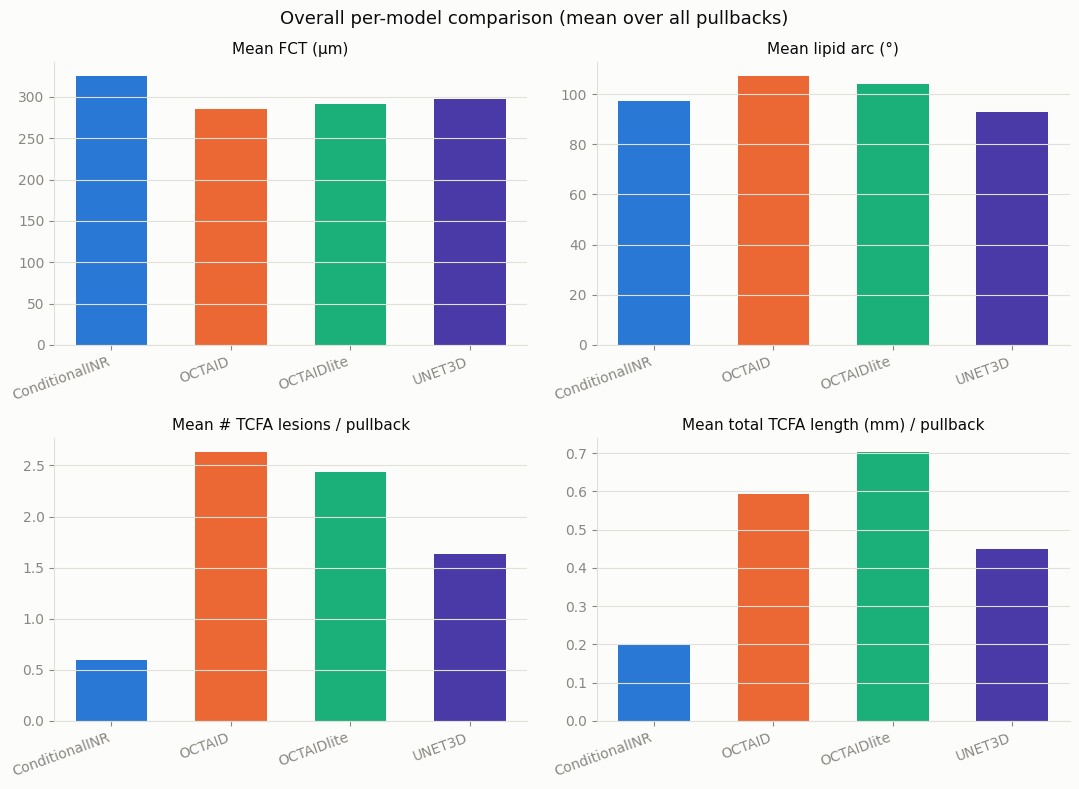

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
metrics = [
    ("Mean_FCT_um",           "Mean FCT (\u00b5m)"),
    ("Mean_Lipid_Arc_deg",    "Mean lipid arc (\u00b0)"),
    ("n_TCFA_lesions",        "Mean # TCFA lesions / pullback"),
    ("total_TCFA_length_mm",  "Mean total TCFA length (mm) / pullback"),
]
ov = overall.set_index("model").reindex(MODEL_ORDER)

for ax, (col, title) in zip(axes.ravel(), metrics):
    colors = [model_color(m) for m in ov.index]
    ax.bar(ov.index, ov[col], color=colors, width=0.6)
    ax.set_title(title, color=INK, fontsize=11)
    ax.set_xticklabels(ov.index, rotation=20, ha="right")
    ax.grid(axis="x", visible=False)

fig.suptitle("Overall per-model comparison (mean over all pullbacks)", fontsize=13, color=INK)
fig.tight_layout()
plt.show()

## 2. Lipid arc per pullback, all models

One dot+line per model across every pullback (`Per_Pullback_Summary.Mean_Lipid_Arc_deg`).
Pullbacks are sorted by the **cross-model average** so the overall trend reads left-to-right
and any single model's outliers are easy to spot against the others.

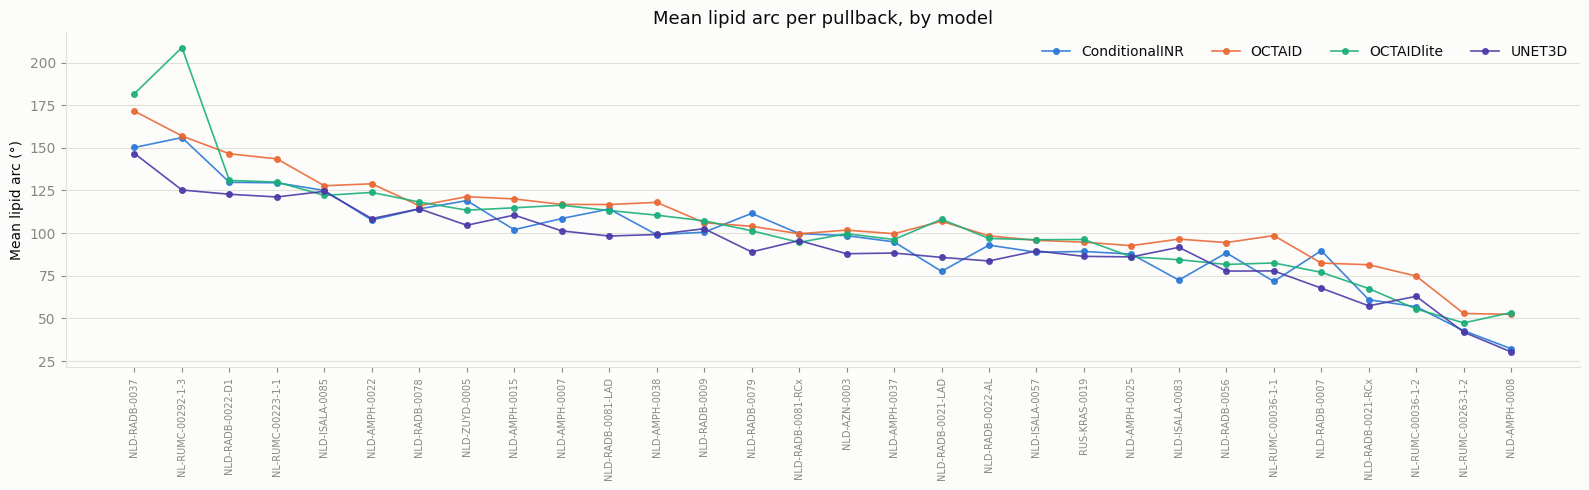

In [5]:
pivot_arc = per_pb.pivot(index="pullback", columns="model", values="Mean_Lipid_Arc_deg")
pivot_arc = pivot_arc[MODEL_ORDER]
order = pivot_arc.mean(axis=1).sort_values(ascending=False).index
pivot_arc = pivot_arc.loc[order]

fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(pivot_arc))
for m in MODEL_ORDER:
    ax.plot(x, pivot_arc[m], marker="o", markersize=4, linewidth=1.2,
            color=model_color(m), label=m, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(pivot_arc.index, rotation=90, fontsize=7)
ax.set_ylabel("Mean lipid arc (\u00b0)")
ax.set_title("Mean lipid arc per pullback, by model", fontsize=13, color=INK)
ax.legend(frameon=False, ncol=4, loc="upper right")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## 3. TCFA lesions per pullback, all models

Same layout as above, for `n_TCFA_lesions` (count of TCFA-positive runs per pullback --
`--tcfa_min_consecutive_frames` was left at 1, so this includes single-frame runs too;
see `TCFA_Lesions.meets_min_length` if you want to apply a stricter continuity cutoff
post-hoc without rerunning).

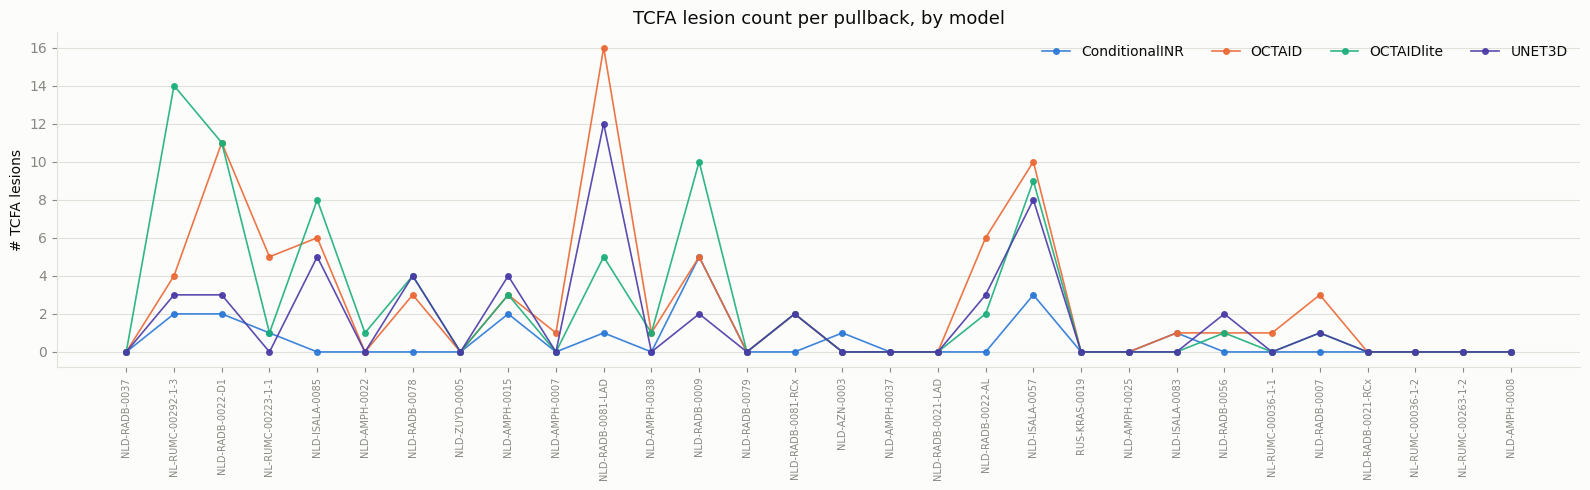

In [6]:
pivot_tcfa = per_pb.pivot(index="pullback", columns="model", values="n_TCFA_lesions")
pivot_tcfa = pivot_tcfa[MODEL_ORDER].loc[order]  # same pullback order as Figure 2

fig, ax = plt.subplots(figsize=(16, 5))
for m in MODEL_ORDER:
    ax.plot(x, pivot_tcfa[m], marker="o", markersize=4, linewidth=1.2,
            color=model_color(m), label=m, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(pivot_tcfa.index, rotation=90, fontsize=7)
ax.set_ylabel("# TCFA lesions")
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_title("TCFA lesion count per pullback, by model", fontsize=13, color=INK)
ax.legend(frameon=False, ncol=4, loc="upper right")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## 4. TCFA concordance heatmap

Where do models actually agree on *which* pullbacks are TCFA-positive, not just the
aggregate count? Sequential single-hue (magnitude, not identity) -- darker = more lesions
detected in that pullback by that model. A pullback with a dark cell in one column and a
blank column next to it is a genuine model disagreement worth a closer look (e.g. via
Figure 6 below).

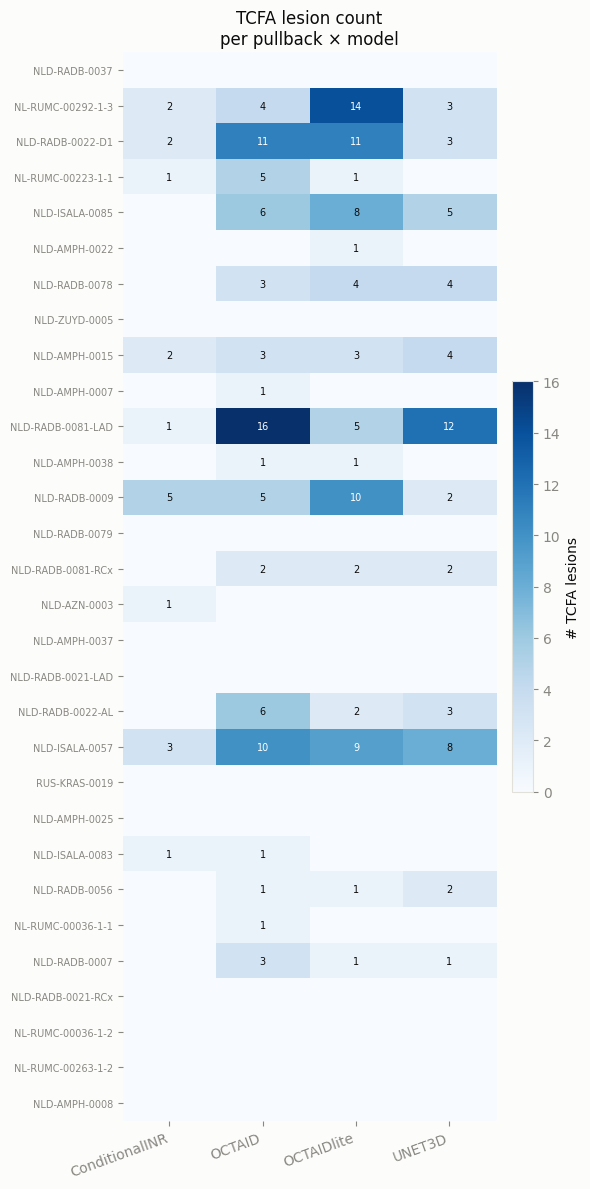

In [7]:
pivot_heat = pivot_tcfa.copy()  # reuse the same pullback order

fig, ax = plt.subplots(figsize=(6, 12))
im = ax.imshow(pivot_heat.values, aspect="auto", cmap="Blues", vmin=0)
ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER, rotation=20, ha="right")
ax.set_yticks(range(len(pivot_heat)))
ax.set_yticklabels(pivot_heat.index, fontsize=7)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(pivot_heat.shape[0]):
    for j in range(pivot_heat.shape[1]):
        v = pivot_heat.values[i, j]
        if v > 0:
            ax.text(j, i, int(v), ha="center", va="center",
                    fontsize=7, color="white" if v > pivot_heat.values.max() / 2 else INK)

cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
cbar.set_label("# TCFA lesions")
ax.set_title("TCFA lesion count\nper pullback \u00d7 model", fontsize=12, color=INK)
fig.tight_layout()
plt.show()

## 5. Frame-level curves for the pullback with the most TCFA signal

Picks the pullback with the highest summed `total_TCFA_length_mm` across all 4 models,
then plots all 5 continuous metrics -- FCT, lipid arc, and (previously missing from
this notebook) calcium arc/depth/thickness -- **per frame** (not just the per-pullback
mean) so you can see whether the models track the same underlying curve shape or
diverge/get noisy -- the direct way to tell "real disagreement" from "one model's
curve is jagged."

Frames excluded via the exclusion excel (guiding catheter / artifact, `Inclusion == 0`)
are left as gaps (NaN), not connected across. A curve that's `NaN` even on included
frames means that model found no lipid/calcium there at all (not zero-filled here --
this is a single-model view per Section 5's helper note, not the paired comparison).

Example pullback: NLD-ISALA-0057 (summed total_TCFA_length_mm across models = 11.60 mm)


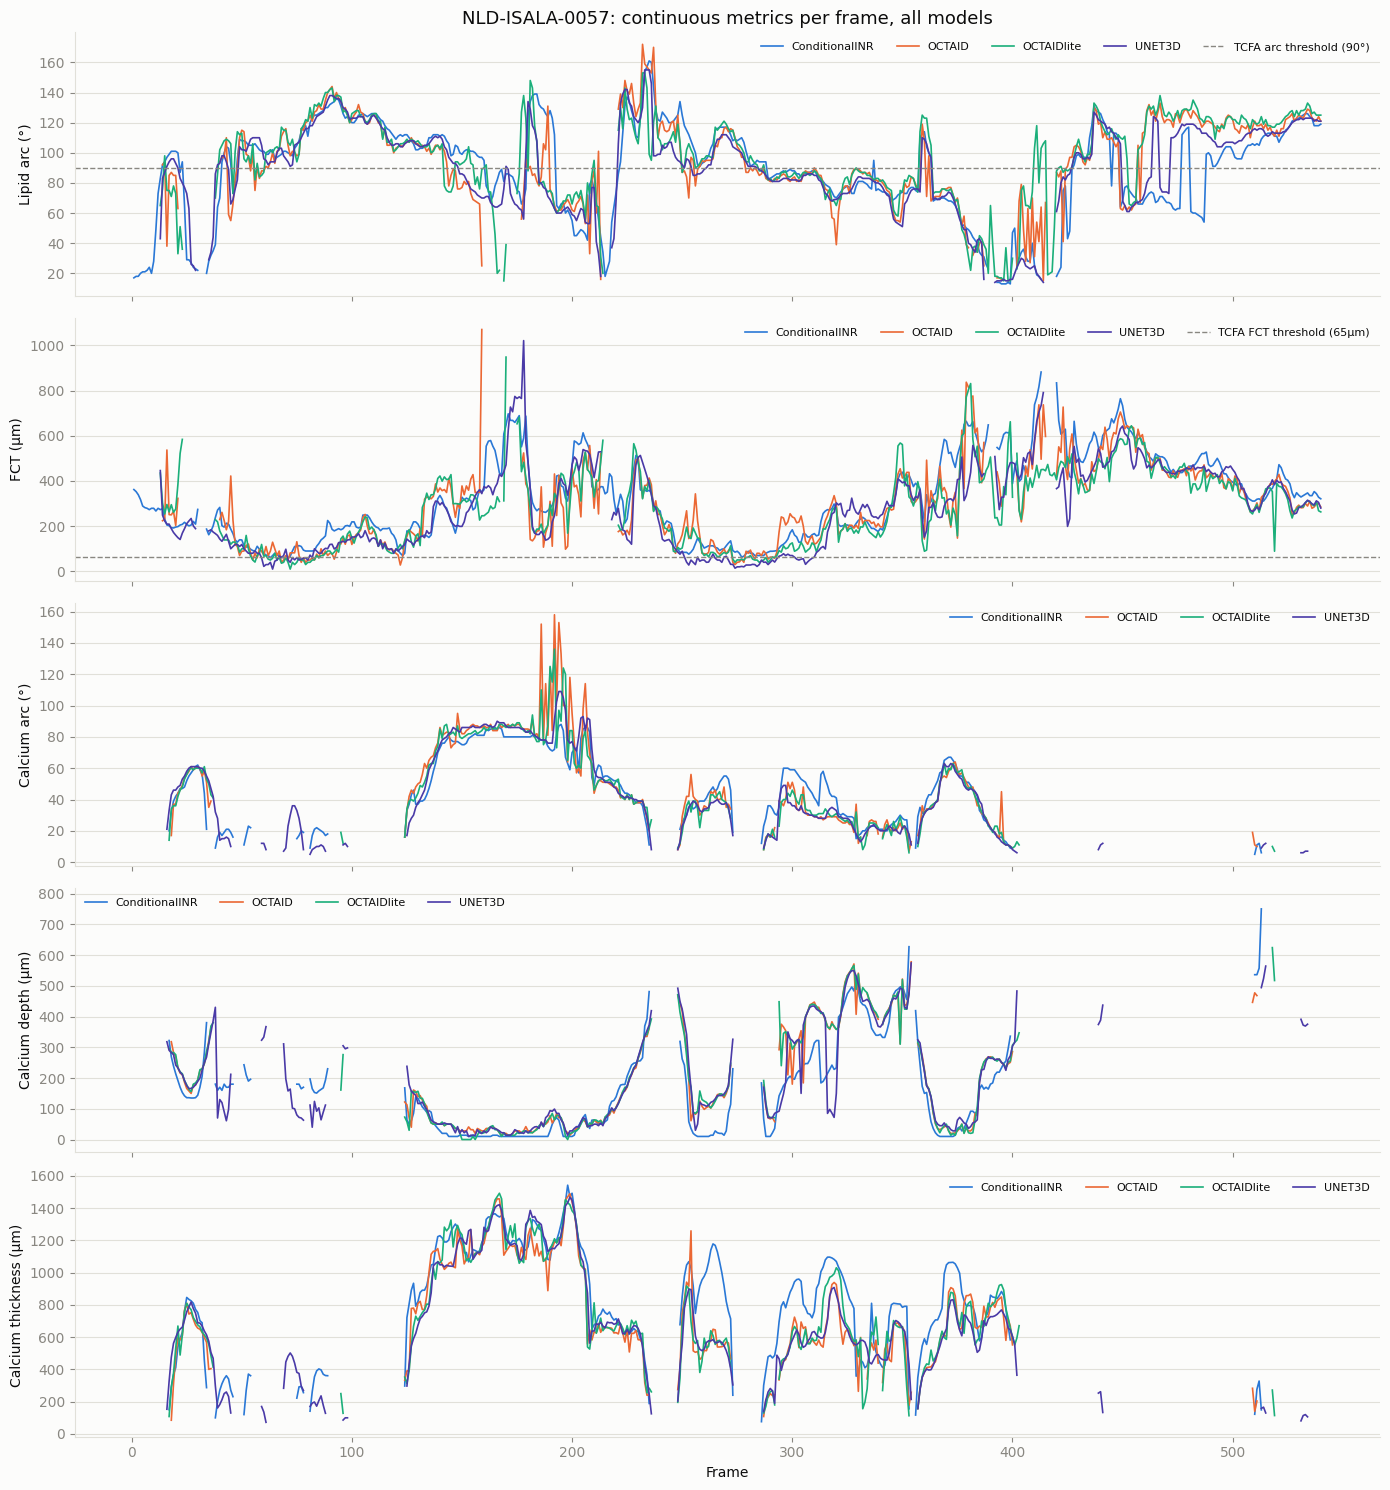

In [8]:
totals_by_pb = per_pb.groupby("pullback")["total_TCFA_length_mm"].sum().sort_values(ascending=False)
example_pid = totals_by_pb.index[1]
print(f"Example pullback: {example_pid} (summed total_TCFA_length_mm across models = "
      f"{totals_by_pb.iloc[0]:.2f} mm)")

metric_cols = list(CONTINUOUS_METRICS)
sub = frames[frames["pullback"] == example_pid].copy()
sub.loc[sub["Inclusion"] == 0, metric_cols] = np.nan

thresholds = {
    "FCT_um":        (65, "TCFA FCT threshold (65µm)"),
    "Lipid_Arc_deg": (90, "TCFA arc threshold (90°)"),
}

fig, axes = plt.subplots(len(metric_cols), 1, figsize=(14, 3 * len(metric_cols)), sharex=True)
for ax, col in zip(axes, metric_cols):
    for m in MODEL_ORDER:
        s = sub[sub["model"] == m].sort_values("frame_1based")
        ax.plot(s["frame_1based"], s[col], color=model_color(m), label=m, linewidth=1.2)
    if col in thresholds:
        val, thr_label = thresholds[col]
        ax.axhline(val, color=INK_MUTED, linestyle="--", linewidth=1, label=thr_label)
    ax.set_ylabel(CONTINUOUS_METRICS[col])
    ax.grid(axis="x", visible=False)
    ax.legend(frameon=False, ncol=5, fontsize=8)

axes[-1].set_xlabel("Frame")
axes[0].set_title(f"{example_pid}: continuous metrics per frame, all models", fontsize=13, color=INK)
fig.tight_layout()
plt.show()

## 6. Per-class mean area, all models

`Mean_Area_<class>_mm2` from `Overall_Per_Model`, one group of bars per class. Useful for
spotting systematic over/under-segmentation of a specific class by one model relative to
the others (e.g. the lipid-oversensitivity question this project has been tracking) rather
than relying on a single aggregate Dice-style number.

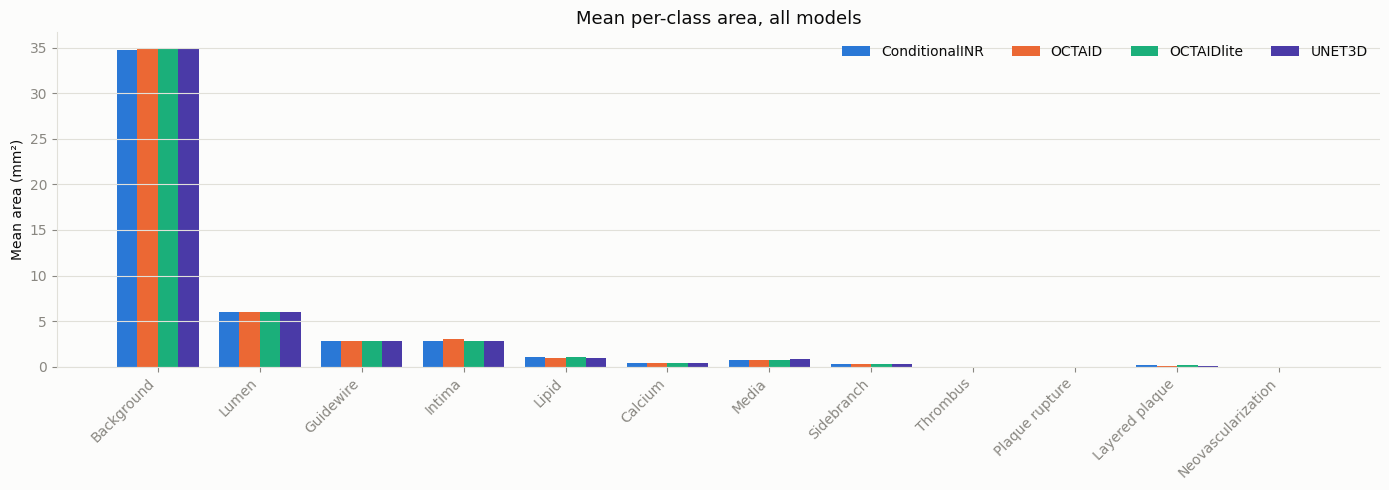

In [9]:
area_cols = [c for c in overall.columns if c.startswith("Mean_Area_")]
class_names = [c.replace("Mean_Area_", "").replace("_mm2", "") for c in area_cols]

area_long = overall.set_index("model")[area_cols].reindex(MODEL_ORDER)
area_long.columns = class_names

fig, ax = plt.subplots(figsize=(14, 5))
n_classes = len(class_names)
n_models = len(MODEL_ORDER)
bar_w = 0.8 / n_models
x = np.arange(n_classes)

for i, m in enumerate(MODEL_ORDER):
    ax.bar(x + i * bar_w, area_long.loc[m], width=bar_w, color=model_color(m), label=m)

ax.set_xticks(x + bar_w * (n_models - 1) / 2)
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_ylabel("Mean area (mm\u00b2)")
ax.set_title("Mean per-class area, all models", fontsize=13, color=INK)
ax.legend(frameon=False, ncol=4)
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## 7. Continuous metrics per frame, ALL pullbacks pooled (not per-pullback means)

Every included frame's raw value across all 30 pullbacks, one box per model -- not
`Per_Pullback_Summary`'s per-pullback mean. Covers all 5 continuous metrics, including
calcium arc/depth/thickness (previously missing from this notebook entirely -- see the
helper note above Section 5).

`n=` in each x-label is how many included frames actually had that structure present
for that model -- a model with a much smaller `n` here is finding the structure in
fewer frames overall, which a mean-per-pullback view would hide.

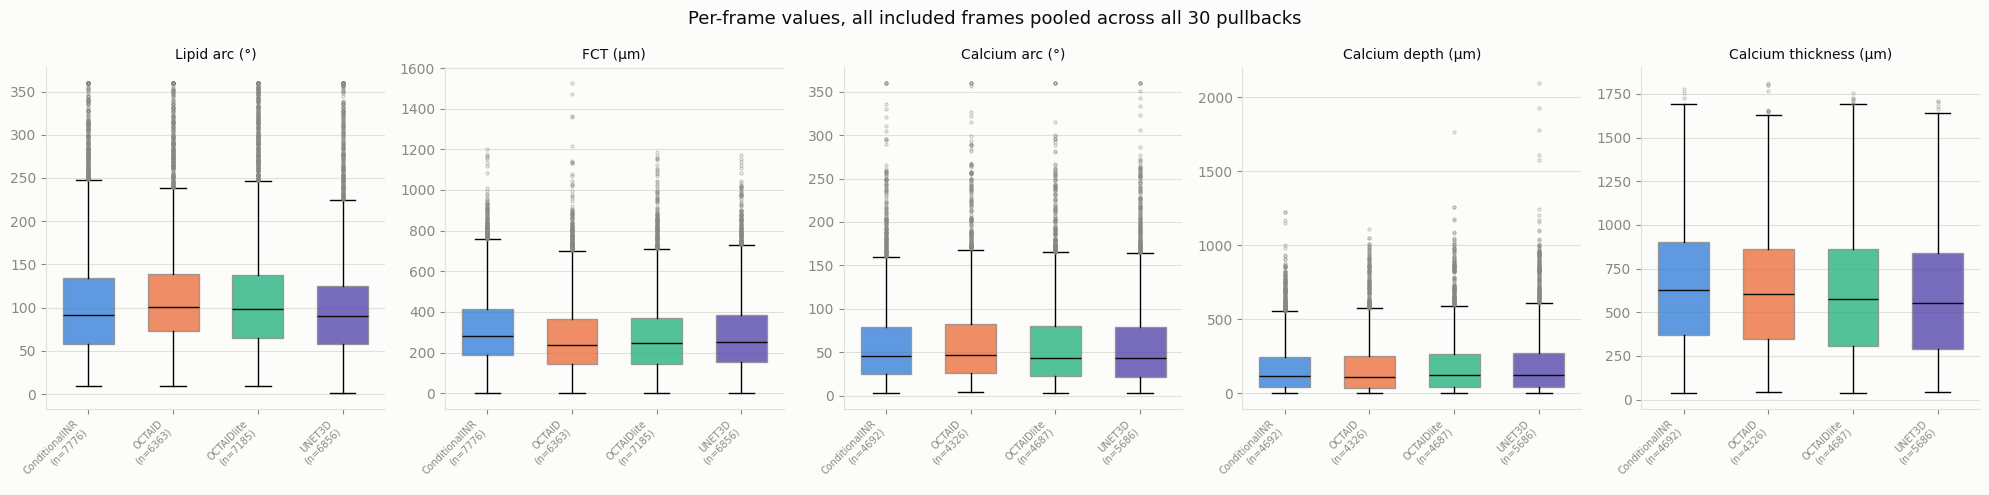

In [10]:
fig, axes = plt.subplots(1, len(CONTINUOUS_METRICS), figsize=(4 * len(CONTINUOUS_METRICS), 5))
for ax, (col, label) in zip(axes, CONTINUOUS_METRICS.items()):
    data = [pooled_frame_values(col, m) for m in MODEL_ORDER]
    bp = ax.boxplot(data, patch_artist=True, widths=0.6, showfliers=True,
                     flierprops=dict(markersize=2, markeredgecolor=INK_MUTED, alpha=0.4))
    for patch, m in zip(bp["boxes"], MODEL_ORDER):
        patch.set_facecolor(model_color(m))
        patch.set_alpha(0.75)
        patch.set_edgecolor(INK_MUTED)
    for median in bp["medians"]:
        median.set_color(INK)
    ax.set_xticks(range(1, len(MODEL_ORDER) + 1))
    ax.set_xticklabels([f"{m}\n(n={len(d)})" for m, d in zip(MODEL_ORDER, data)],
                        rotation=45, ha="right", fontsize=7)
    ax.set_title(label, fontsize=10, color=INK)
    ax.grid(axis="x", visible=False)

fig.suptitle("Per-frame values, all included frames pooled across all 30 pullbacks", fontsize=13, color=INK)
fig.tight_layout()
plt.show()

## 8. Model agreement, per FRAME (not per-pullback means)

Every included `(pullback, frame)` as one point -- not `Per_Pullback_Summary`'s
per-pullback mean, so individual disagreeing frames aren't averaged away. When
one model finds the structure and the other doesn't at the same frame, that frame
is kept with the missing side plotted as **0** (not dropped) -- so "model A sees a
40° lipid arc, model B sees none" shows up as a point at `(40, 0)` on the axis,
rather than silently disappearing from the comparison. A frame where *neither*
model detects the structure has nothing to compare and is dropped. Subplot titles
show how many points came from a one-sided zero-fill. Swap `MODEL_A`/`MODEL_B`
for a different pair.

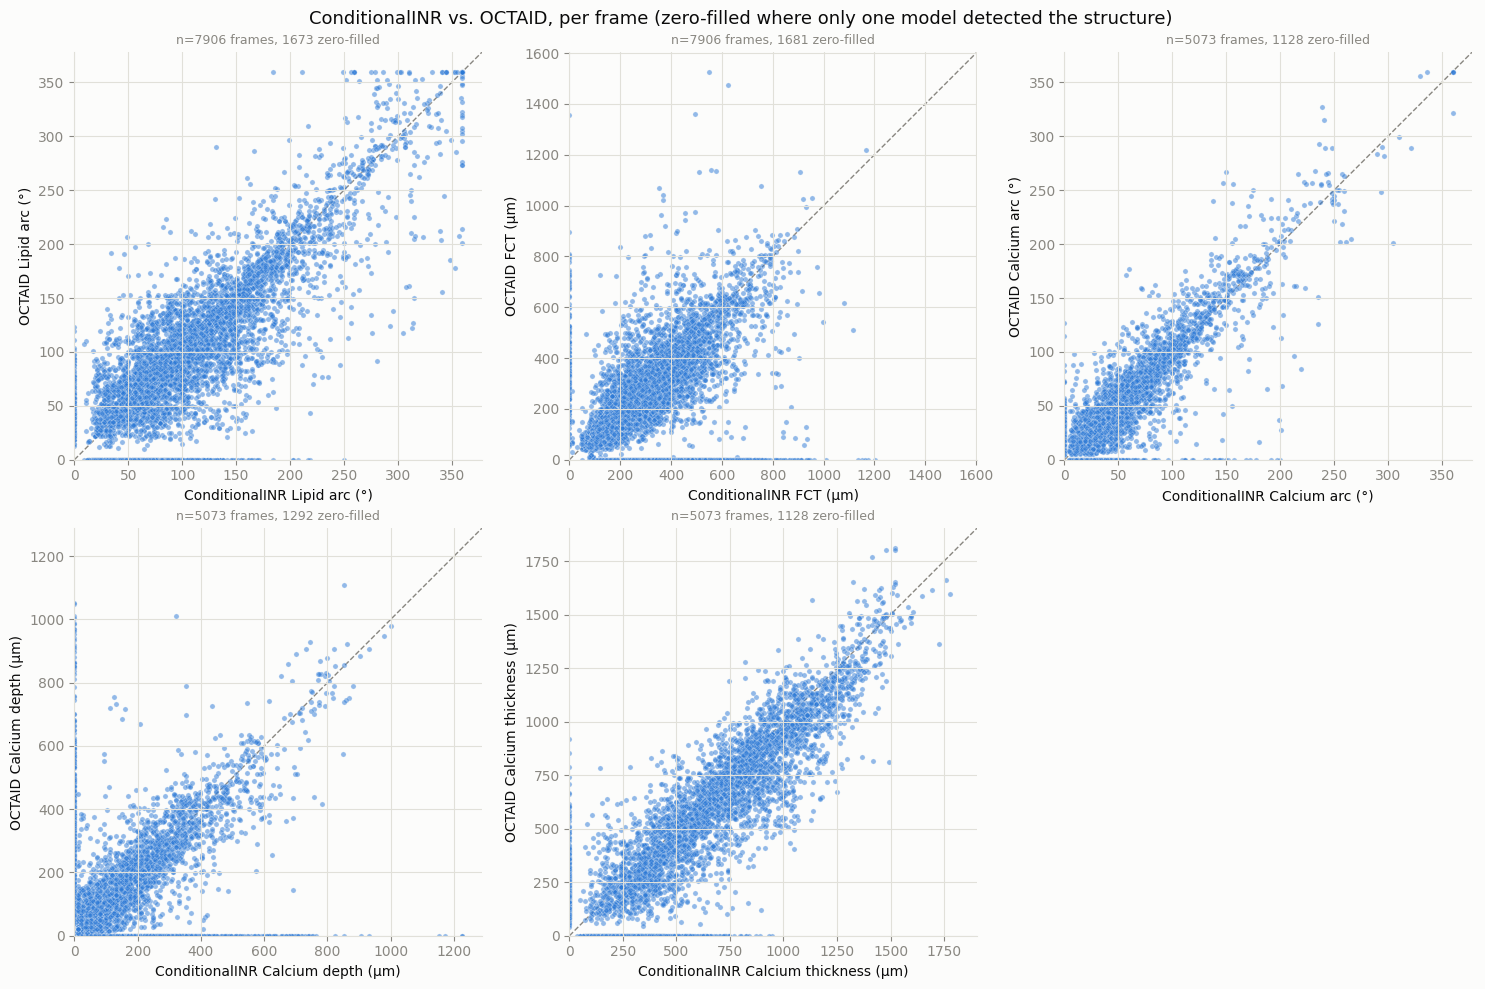

In [11]:
MODEL_A, MODEL_B = "ConditionalINR", "OCTAID"

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
for ax, (col, label) in zip(axes, CONTINUOUS_METRICS.items()):
    paired = paired_frame_table(col, MODEL_A, MODEL_B)
    a, b = paired[MODEL_A], paired[MODEL_B]
    n_zero_fill = int(((a == 0) ^ (b == 0)).sum())  # exactly one side zero-filled
    lim = [0, max(a.max(), b.max()) * 1.05] if len(paired) else [0, 1]
    ax.plot(lim, lim, color=INK_MUTED, linestyle="--", linewidth=1, zorder=0)
    ax.scatter(a, b, color=model_color(MODEL_A), edgecolor="white", linewidth=0.3,
               s=14, alpha=0.5)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"{MODEL_A} {label}")
    ax.set_ylabel(f"{MODEL_B} {label}")
    ax.set_title(f"n={len(paired)} frames, {n_zero_fill} zero-filled", fontsize=9, color=INK_MUTED)
    ax.set_aspect("equal")

for ax in axes[len(CONTINUOUS_METRICS):]:
    ax.axis("off")

fig.suptitle(f"{MODEL_A} vs. {MODEL_B}, per frame (zero-filled where only one model "
             f"detected the structure)", fontsize=13, color=INK)
fig.tight_layout()
plt.show()

## 9. Comparing per-class area across all 30 pullbacks, properly paired

The same 30 pullbacks were predicted by all 4 models -- this is a **paired /
repeated-measures** design, not 4 independent samples. Two consequences:

- Frames are aggregated to one value per pullback first (`Mean_Area_<class>_mm2`,
  already computed), *then* compared across pullbacks -- pooling every frame from
  every pullback directly would let longer pullbacks dominate the result.
- Models are compared with **paired** methods (Friedman + pairwise Wilcoxon
  signed-rank) rather than treating each model's 30 values as unrelated groups,
  since e.g. `NLD-AMPH-0007`'s ConditionalINR/OCTAID/OCTAIDlite/UNET3D values are
  the same underlying vessel, not independent observations.

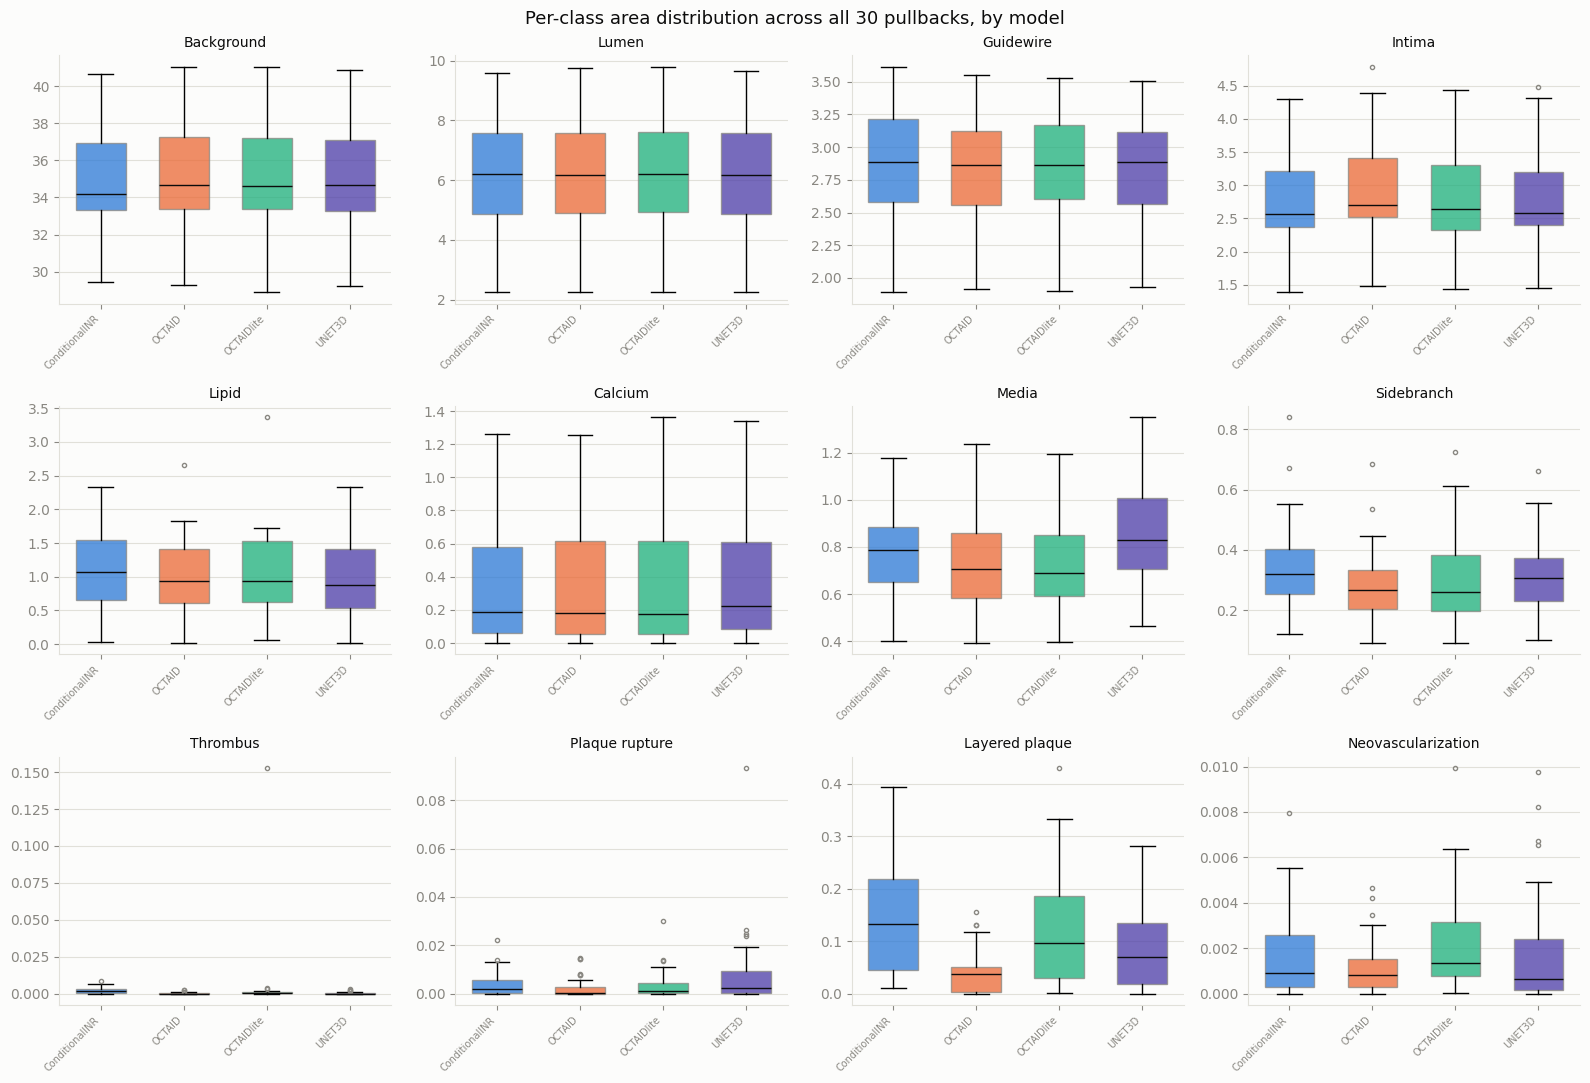

In [12]:
# ---- 9a. Marginal distribution per class (boxplot across all 30 pullbacks) ----
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for ax, cls in zip(axes.ravel(), class_names):
    col = f"Mean_Area_{cls}_mm2"
    data = [per_pb.loc[per_pb["model"] == m, col].dropna().values for m in MODEL_ORDER]
    bp = ax.boxplot(data, patch_artist=True, widths=0.6, showfliers=True,
                     flierprops=dict(markersize=3, markeredgecolor=INK_MUTED))
    for patch, m in zip(bp["boxes"], MODEL_ORDER):
        patch.set_facecolor(model_color(m))
        patch.set_alpha(0.75)
        patch.set_edgecolor(INK_MUTED)
    for median in bp["medians"]:
        median.set_color(INK)
    ax.set_xticks(range(1, len(MODEL_ORDER) + 1))
    ax.set_xticklabels(MODEL_ORDER, rotation=45, ha="right", fontsize=7)
    ax.set_title(cls, fontsize=10, color=INK)
    ax.grid(axis="x", visible=False)

fig.suptitle("Per-class area distribution across all 30 pullbacks, by model", fontsize=13, color=INK)
fig.tight_layout()
plt.show()

### 9b. Is the difference real? Friedman test + paired Wilcoxon per class

`friedman_p` tests whether the 4 models differ *at all* for that class (omnibus).
The six pairwise columns are Wilcoxon signed-rank p-values, **Holm-corrected**
across the 6 comparisons per class (so the correction doesn't get stricter just
because more classes are shown). Cells below 0.05 are highlighted -- read the
omnibus column first; a pairwise cell only matters if the omnibus for that row is
also significant.

In [13]:
from itertools import combinations

from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

pairs = list(combinations(MODEL_ORDER, 2))
rows = []
for cls in class_names:
    col = f"Mean_Area_{cls}_mm2"
    wide = per_pb.pivot(index="pullback", columns="model", values=col)[MODEL_ORDER].dropna()

    _, p_omnibus = friedmanchisquare(*[wide[m] for m in MODEL_ORDER])

    raw_pvals = [wilcoxon(wide[a], wide[b]).pvalue for a, b in pairs]
    _, p_corrected, _, _ = multipletests(raw_pvals, method="holm")

    row = {"class": cls, "n_pullbacks": len(wide), "friedman_p": p_omnibus}
    row.update({f"{a} vs {b}": p for (a, b), p in zip(pairs, p_corrected)})
    rows.append(row)

stats_df = pd.DataFrame(rows).set_index("class")

def highlight_sig(v):
    if isinstance(v, float) and v < 0.05:
        return "background-color: #fbe3e3; color: #9a1c1c; font-weight: bold"
    return ""

stats_df.style.format({c: "{:.4f}" for c in stats_df.columns if c != "n_pullbacks"}) \
    .applymap(highlight_sig, subset=[c for c in stats_df.columns if c not in ("n_pullbacks",)])

C:\Users\z923198\AppData\Local\Temp\ipykernel_30452\1754458770.py:29: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(highlight_sig, subset=[c for c in stats_df.columns if c not in ("n_pullbacks",)])


,n_pullbacks,friedman_p,ConditionalINR vs OCTAID,ConditionalINR vs OCTAIDlite,ConditionalINR vs UNET3D,OCTAID vs OCTAIDlite,OCTAID vs UNET3D,OCTAIDlite vs UNET3D
class,,,,,,,,
Background,30,0.0000,0.0000,0.0004,0.7415,0.9354,0.0001,0.0077
Lumen,30,0.0591,0.8403,1.0000,0.2667,1.0000,0.1042,0.0928
Guidewire,30,0.0160,0.2983,0.4397,0.5840,1.0000,0.5840,1.0000
Intima,30,0.0000,0.0000,0.0691,0.0173,0.0000,0.0000,0.8078
Lipid,30,0.0087,0.0109,0.2667,0.0062,0.6162,0.6162,0.6162
Calcium,30,0.0000,0.0845,0.0845,0.0156,0.8872,0.0000,0.0000
Media,30,0.0000,0.0001,0.0000,0.0000,0.0062,0.0000,0.0000
Sidebranch,30,0.0000,0.0054,0.0361,0.4571,0.4571,0.0000,0.0052
Thrombus,30,0.0000,0.0000,0.0012,0.0001,0.0000,0.7731,0.0011


### 9c. Full paired detail for one class

Every pullback as a light connecting line across the 4 models, colored dots on
top -- shows both the paired structure (which the boxplots above discard) and
the overall shift. Change `CLASS_TO_INSPECT` to look at any other class the
table above flags as significant.

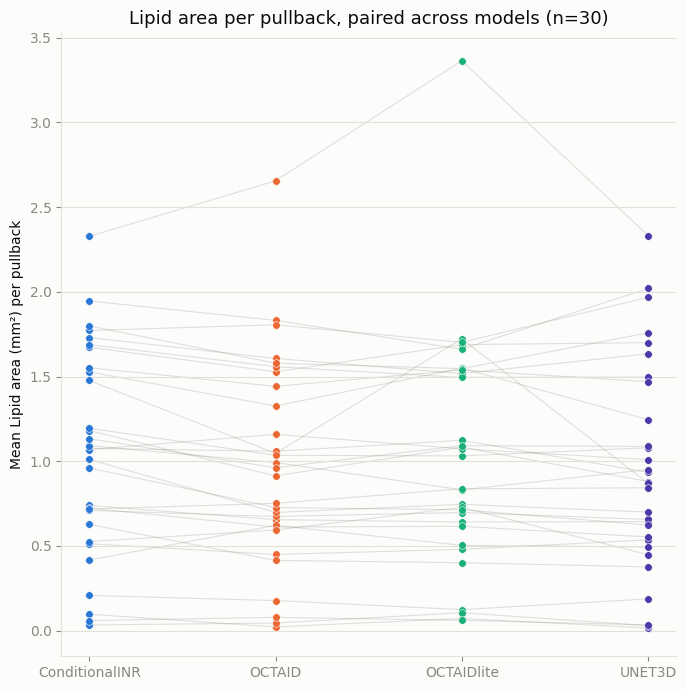

In [14]:
CLASS_TO_INSPECT = "Lipid"

col = f"Mean_Area_{CLASS_TO_INSPECT}_mm2"
wide = per_pb.pivot(index="pullback", columns="model", values=col)[MODEL_ORDER].dropna()

fig, ax = plt.subplots(figsize=(7, 7))
x_positions = np.arange(len(MODEL_ORDER))
for _, row in wide.iterrows():
    ax.plot(x_positions, row.values, color=INK_MUTED, alpha=0.25, linewidth=0.8, zorder=1)
for i, m in enumerate(MODEL_ORDER):
    ax.scatter(np.full(len(wide), i), wide[m], color=model_color(m), s=30,
               zorder=2, edgecolor="white", linewidth=0.4)

ax.set_xticks(x_positions)
ax.set_xticklabels(MODEL_ORDER)
ax.set_ylabel(f"Mean {CLASS_TO_INSPECT} area (mm\u00b2) per pullback")
ax.set_title(f"{CLASS_TO_INSPECT} area per pullback, paired across models "
             f"(n={len(wide)})", fontsize=13, color=INK)
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## 10. Interactive: per-class area over one pullback, all models

`Area_<class>_mm2` per frame (`Frame_Level`), not the `Mean_Area_...` per-pullback
average from Sections 6/9 -- this is the actual curve along the pullback, one line
per `(class, model)` combination.

Interactive controls (ipywidgets -- runs live, needs a Jupyter kernel):
- **Pullback dropdown** -- picks which of the 30 pullbacks to plot.
- **Class checkboxes** -- click to show/hide a class; all 4 models for that class
  toggle together. `Background`/`Lumen` start unchecked since their area is
  orders of magnitude larger than every pathology class and would flatten the
  rest of the y-axis otherwise -- check them back on if you want them.
- **Model checkboxes** -- click to show/hide an individual model's lines across
  every selected class. All 4 start checked.

Color encodes **model** (same fixed `MODEL_COLORS` as every other figure in this
notebook) -- with 4 models on screen at once, telling them apart is the harder job,
so color does it. Linestyle encodes **class** instead (solid/dashed/dotted/dashdot/
long-dash/dash-dot-dot, cycling past 6 classes -- fine in practice since the typical
use here is 1-2 classes at a time, and each is still named in its own legend).
Frames excluded via the exclusion excel (`Inclusion == 0`) are left as gaps, same
convention as Section 5.

In [15]:
import ipywidgets as widgets
from IPython.display import display

AREA_CLASS_NAMES = [c.replace("Area_", "").replace("_mm2", "")
                     for c in frames.columns if c.startswith("Area_")]

# ---- Color encodes MODEL (same MODEL_COLORS as every other figure) -- with 4 models
# on screen at once, distinguishing them is the harder job and color does it better
# than linestyle. Class gets a fixed linestyle instead (never re-cycled up to 6
# classes; repeats past that -- fine since the common case is 1-2 classes selected
# at a time, and each selected class is still named in its own legend). ----
CLASS_LINESTYLES_POOL = ["-", "--", ":", "-.", (0, (5, 2)), (0, (3, 1, 1, 1, 1, 1))]
CLASS_LINESTYLES = {cls: CLASS_LINESTYLES_POOL[i % len(CLASS_LINESTYLES_POOL)]
                     for i, cls in enumerate(AREA_CLASS_NAMES)}

_PULLBACK_OPTIONS = sorted(frames["pullback"].unique())
_DEFAULT_UNCHECKED = {"Background", "Lumen"}

pullback_dropdown = widgets.Dropdown(
    options=_PULLBACK_OPTIONS, value=_PULLBACK_OPTIONS[0], description="Pullback:",
    style={"description_width": "initial"},
)
class_checkboxes = {
    cls: widgets.Checkbox(value=cls not in _DEFAULT_UNCHECKED, description=cls, indent=False)
    for cls in AREA_CLASS_NAMES
}
checkbox_grid = widgets.GridBox(
    list(class_checkboxes.values()),
    layout=widgets.Layout(grid_template_columns="repeat(4, 220px)"),
)
model_checkboxes = {
    m: widgets.Checkbox(
        value=True, description=m, indent=False,
        layout=widgets.Layout(width="180px"),
        style={"background": model_color(m)},
    )
    for m in MODEL_ORDER
}
model_checkbox_row = widgets.HBox(list(model_checkboxes.values()))
plot_output = widgets.Output()

def redraw_class_area_figure(*_):
    pid = pullback_dropdown.value
    selected = [c for c in AREA_CLASS_NAMES if class_checkboxes[c].value]
    selected_models = [m for m in MODEL_ORDER if model_checkboxes[m].value]

    sub = frames[frames["pullback"] == pid].copy()
    selected_cols = [f"Area_{c}_mm2" for c in selected]
    if selected_cols:
        sub.loc[sub["Inclusion"] == 0, selected_cols] = np.nan

    with plot_output:
        plot_output.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(14, 6))
        for cls in selected:
            col = f"Area_{cls}_mm2"
            for m in selected_models:
                s = sub[sub["model"] == m].sort_values("frame_1based")
                ax.plot(s["frame_1based"], s[col], color=model_color(m),
                        linestyle=CLASS_LINESTYLES[cls], linewidth=1.4, alpha=0.9)

        ax.set_xlabel("Frame")
        ax.set_ylabel("Area (mm²)")
        ax.set_title(f"{pid}: per-class area per frame, all models", fontsize=13, color=INK)
        ax.grid(axis="x", visible=False)

        if selected_models:
            model_handles = [plt.Line2D([0], [0], color=model_color(m), linewidth=2) for m in selected_models]
            model_legend = ax.legend(model_handles, selected_models, title="Model (color)", frameon=False,
                                      loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8)
            ax.add_artist(model_legend)
        if selected:
            class_handles = [plt.Line2D([0], [0], color=INK, linestyle=CLASS_LINESTYLES[c]) for c in selected]
            ax.legend(class_handles, selected, title="Class (linestyle)", frameon=False,
                      loc="upper left", bbox_to_anchor=(1.01, 0.45), fontsize=8)

        fig.tight_layout()
        plt.show()

pullback_dropdown.observe(redraw_class_area_figure, names="value")
for cb in class_checkboxes.values():
    cb.observe(redraw_class_area_figure, names="value")
for cb in model_checkboxes.values():
    cb.observe(redraw_class_area_figure, names="value")

display(widgets.VBox([pullback_dropdown, checkbox_grid, model_checkbox_row, plot_output]))
redraw_class_area_figure()